# 1. Introducción a MNIST

## PARTE 1. Instalar los paquetes y comprobación 

In [4]:
import torch
import torchvision
import matplotlib.pyplot as plt

print(torch.__version__)
print(torchvision.__version__)

2.14.0+cpu
0.29.0+cpu


## PARTE 2. Descarga del dataset y visualización 

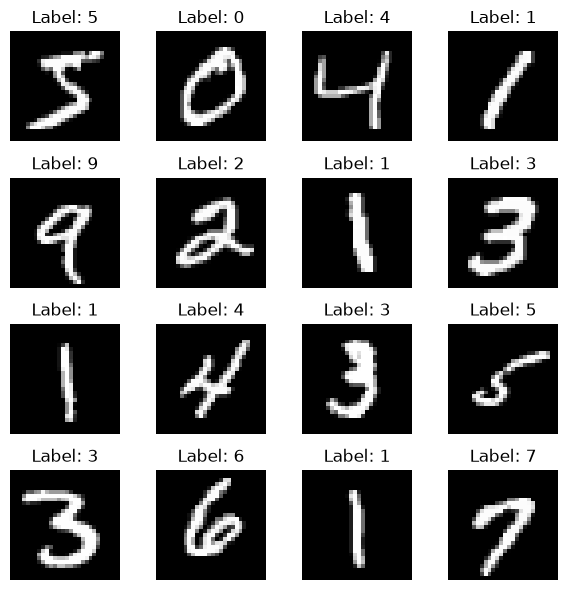

In [5]:
from torchvision.datasets import MNIST

dataset = MNIST(root="../data", train=True, download=True)

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    image, label = dataset[i]
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")
    
plt.tight_layout()
plt.show()

## PARTE 3. Inspeccionar una imagen

In [6]:
from torchvision import transforms

transform = transforms.ToTensor()

# imagen de ejemplo 
ej_image, ej_label = dataset[0]

ej_tensor= transform(ej_image)
print(ej_tensor.shape)
print(type(ej_tensor))
print(torch.min(ej_tensor))
print(torch.max(ej_tensor))

torch.Size([1, 28, 28])
<class 'torch.Tensor'>
tensor(0.)
tensor(1.)


## PARTE 4. Binarizar una imagen 

In [7]:
def binarizar(dato, t=0.5):

    image, label = dataset[dato]

    transform = transforms.ToTensor()
    tensor = transform(image)

    for i in range(tensor.shape[1]):
        for j in range(tensor.shape[2]):

            if tensor[0, i, j] >= t:
                tensor[0, i, j] = 1
            else:
                tensor[0, i, j] = 0

    return label, tensor

#binarizar(0)

In [8]:
#más elegante y rápido 
def binarizar2(tensor, t=0.5):
    # Esto devuelve un torch.Tensor booleano, el .float() lo convierte en 1 (True) y 0 (False)
    binary_tensor = (tensor >= t).float() 
    return binary_tensor

### Visualicación y conteo de imagenes binarizadas

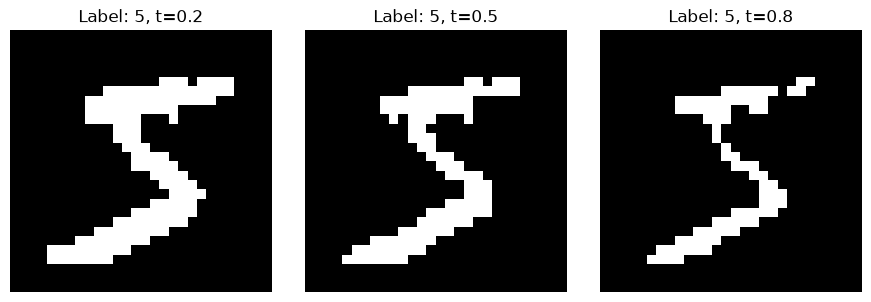

In [9]:
image, label = dataset[0]
tensor = transforms.ToTensor()(image)

ts = [0.2, 0.5, 0.8]

plt.figure(figsize=(9, 3))

for i,t in enumerate(ts):
    binary = binarizar2(tensor, t)

    plt.subplot(1, 3, i + 1)
    plt.imshow(binary.squeeze(), cmap="gray") #squeeze: para eliminar las dimensiones extras de tamaño 1
    plt.title(f"Label: {label}, t={t}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
contador=[0,0,0]

for i,t in enumerate(ts):
    binary = binarizar2(tensor, t)
    # en PyTorch la función .sum() cuenta automáticamente los valores True como 1 y los False como 0
    # .item() extrae el valor numérico puro desde el tensor de PyTorch
    contador[i] = (binary == 1).sum().item()/(28**2)

print(contador)

[0.17091836734693877, 0.14158163265306123, 0.10076530612244898]


## PARTE 6. Estadística del dataset 

<function matplotlib.pyplot.show(close=None, block=None)>

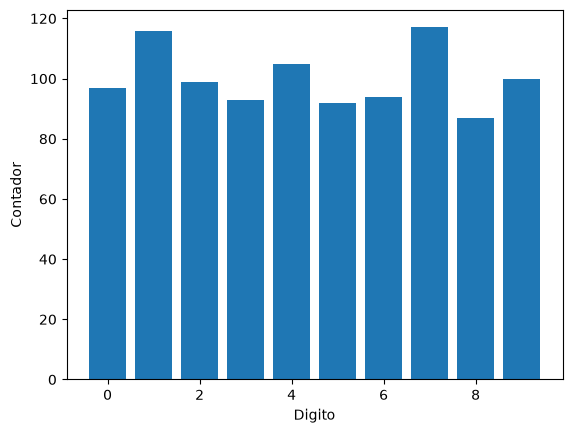

In [79]:
contador= [0]*10

for i in range(1000): 
    image, label = dataset[i]
    contador[label]+=1

plt.figure()
plt.bar(range(10),contador)
plt.xlabel("Digito")
plt.ylabel("Contador")
plt.show

In [14]:
images = []
labels = []

for i in range(1000):
    image, label = dataset[i]
    tensor = transforms.ToTensor()(image)
    images.append(tensor)
    labels.append(label)

images = torch.stack(images)
labels = torch.tensor(labels)

print(images.shape)

torch.Size([1000, 1, 28, 28])


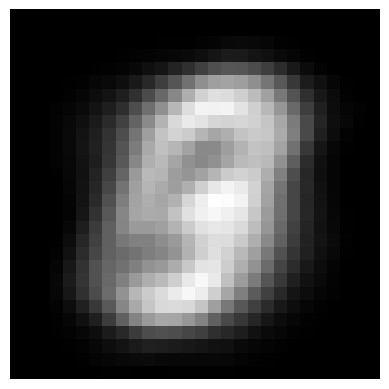

In [15]:
mean_image = images.mean(dim=0)

plt.imshow(mean_image.squeeze(), cmap="gray")
plt.axis("off")
plt.show()

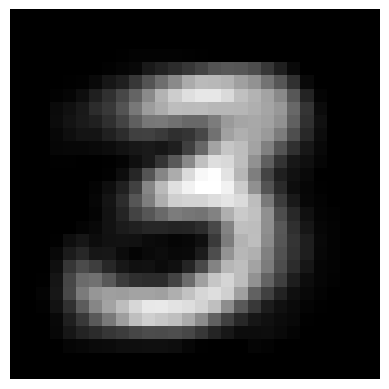

In [17]:
images_3 = images[labels == 3]

mean_3 = images_3.mean(dim=0)

plt.imshow(mean_3.squeeze(), cmap="gray")
plt.axis("off")
plt.show()

# 2. Maximum-likelihood estimation of a Gaussian

## PARTE 1. Generar un dataset de Gaussian data

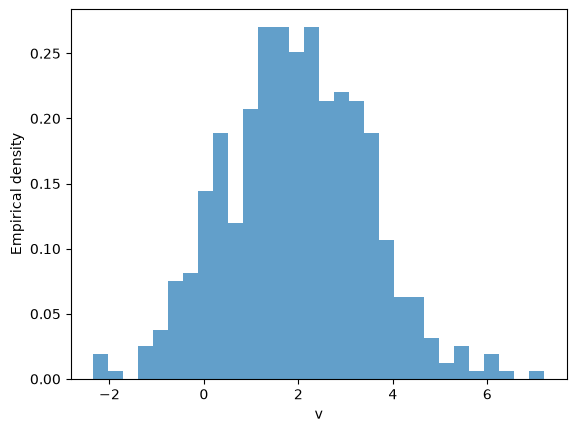

In [18]:
M = 500
mu_true = 2.0
sigma_true = 1.5

# M independent observations from N(mu_true, sigma_true^2)
v = mu_true + sigma_true * torch.randn(M)

plt.hist(v.numpy(), bins=30, density=True, alpha=0.7)
plt.xlabel("v")
plt.ylabel("Empirical density")
plt.show()

## PARTE 2. Calculo de los parametros $\mu$ y $\sigma$ máximizando el log-likelihood

Distribución gaussiana: $p_{\mu,\sigma}(v)= \frac{1}{\sqrt{2\pi}\sigma}exp\left[-\frac{(v-\mu)^2}{2\sigma^2}\right]$

A partir de esta expresión calculamos el likelihood: 
$$p_{\mu,\sigma}(D)= \prod_{m=1}^{M} \frac{1}{\sqrt{2\pi}\sigma}exp\left[-\frac{(v^{(m)}-\mu)^2}{2\sigma^2}\right]$$

Calculamos el log-likelihood: 
$$L(\mu,\sigma)=\frac{1}{M}log(p_{\mu,\sigma}(D))= \frac{1}{M}\sum_{m=1}^{M} log\left(\frac{1}{\sqrt{2\pi}\sigma}exp\left[-\frac{(v^{(m)}-\mu)^2}{2\sigma^2}\right] \right)= -\frac{1}{M}\sum_{m=1}^{M}\left[log(\sqrt{2\pi}\sigma)+\frac{(v^{(m)}-\mu)^2}{2\sigma^2} \right]$$

Ahora calculamos los parametros $\mu_{ML}$ y $\sigma_{ML}$ derivando el log-likelihood he igualandolo a cero. 
$$\frac{\partial L}{\partial \mu}=0 \to \frac{1}{M\sigma^2} \sum_{m=1}^{M} (v^{(m)}-\mu) =0 \to \sum_{m=1}^{M} v^{(m)} - M\mu=0 \to \mu_{ML}= \frac{1}{M}\sum_{m=1}^{M} v^{(m)}$$

$$\frac{\partial L}{\partial \sigma}=0 \to -\frac{1}{\sigma}+\frac{1}{M\sigma^3}\sum_{m=1}^{M}(v^{(m)}-\mu)^2 \to \sigma^2_{ML}= \frac{1}{M}\sum_{m=1}^{M}(v^{(m)}-\mu_{ML})^2

In [19]:
mu_ML = torch.sum(v) / M
sigma2_ML = torch.sum((v - mu_ML) ** 2) / M

print("Media (mu_ML):",mu_ML)
print("Media real:", mu_true)
print("Desviación (sigma_ML):",sigma2_ML**(1/2))
print("Desviación real:", sigma_true)

Media (mu_ML): tensor(1.9682)
Media real: 2.0
Desviación (sigma_ML): tensor(1.5063)
Desviación real: 1.5


## PARTE 3. Repetir el proceso para distintos valores de M 

In [20]:
Ms= [100,300,600,900,1400]

def ML(mu_t,sigma_t,M):
    v= mu_t + sigma_t * torch.randn(M)
    mu_ML = torch.sum(v) / M
    sigma2_ML = torch.sum((v - mu_ML) ** 2) / M
    print("Para M=",M)
    print("Media (mu_ML):",mu_ML)
    print("Desviación (sigma_ML):",sigma2_ML**(1/2))
    print()

for M in Ms: 
    ML(mu_true,sigma_true,M)

Para M= 100
Media (mu_ML): tensor(1.8645)
Desviación (sigma_ML): tensor(1.5126)

Para M= 300
Media (mu_ML): tensor(2.0383)
Desviación (sigma_ML): tensor(1.4240)

Para M= 600
Media (mu_ML): tensor(2.0594)
Desviación (sigma_ML): tensor(1.5275)

Para M= 900
Media (mu_ML): tensor(2.0140)
Desviación (sigma_ML): tensor(1.4916)

Para M= 1400
Media (mu_ML): tensor(1.9831)
Desviación (sigma_ML): tensor(1.4898)

